# Self-Supervised Masked Autoencoder for Chest X-ray Reconstruction

- Step 1: Import libraries and set up environment

Loads PyTorch, torchvision, and data utilities, and sets the number of CPU threads to speed up training.

- Step 2: Convert images into fixed-size patches

Defines a PatchEmbed module that splits each 128×128 grayscale chest X-ray into 64 non-overlapping 16×16 patches and converts each patch into a numerical embedding.

- Step 3: Define the Masked Autoencoder (MAE) model

Builds a Vision Transformer–based MAE that:

Randomly masks a portion of image patches

Encodes only the visible patches using a Transformer encoder

Uses a Transformer decoder to reconstruct the missing (masked) patches

Produces both reconstructed pixels and a global image embedding (CLS token)

- Step 4: Apply random patch masking

Randomly selects a percentage of patches to hide (30% in Stage 1, later 75%) so the model learns to infer missing image regions from context.

- Step 5: Reconstruct masked patches

The decoder predicts pixel values only for the masked patches. It forces the model to learn meaningful image structure rather than copying inputs.

- Step 6: Compute reconstruction loss

Calculates mean squared error (MSE) only on masked patches, comparing predicted patches to the original image patches.

- Step 7: Load and preprocess chest X-ray data

Loads chest X-ray images, converts them to grayscale, resizes them to 128×128, and splits the dataset into training and validation sets.

- Step 8: Train the model in two stages

  - Stage 1: Trains with 30% masking to learn basic spatial features

  - Stage 2: Increases masking to 75% to encourage stronger semantic understanding and robustness

- Step 9: Optimize and monitor training

Uses AdamW optimization and a cosine learning rate schedule, tracking training and validation reconstruction error across epochs.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader, random_split

torch.set_num_threads(9)

# 1) PATCH EMBEDDING + MAE DEFINITION (16×16 patches on 128×128 images)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_chans=1, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.grid_size  = img_size // patch_size    # 8
        self.num_patches = self.grid_size ** 2      # 64
        self.proj = nn.Conv2d(in_channels=in_chans, out_channels=embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B,1,128,128] → conv → [B,256,8,8] → flatten → [B,64,256]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MAE(nn.Module):
    def __init__(self,
                 img_size=128,
                 patch_size=16,
                 in_chans=1,
                 embed_dim=256,
                 mask_ratio=0.30,
                 depth_encoder=4,
                 depth_decoder=2,
                 num_heads=4,
                 mlp_hidden=512):
        super().__init__()

        # 1) Patch embedding
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.num_patches = self.patch_embed.num_patches  # 64
        self.grid_size   = self.patch_embed.grid_size    # 8
        self.patch_size  = patch_size
        self.embed_dim   = embed_dim
        self.mask_ratio  = mask_ratio

        # 2) Encoder: CLS token + positional embedding + TransformerEncoder
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.encoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=mlp_hidden,
            activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth_encoder)

        # 3) Decoder: mask_token + per‐patch positional embedding + small TransformerEncoder
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=mlp_hidden,
            activation='gelu', batch_first=True)
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=depth_decoder)

        # 4) Final head: each decoder output → 16×16 pixels
        self.decoder_head = nn.Linear(embed_dim, patch_size * patch_size)

        # Initialize
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.encoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)

        # Patchify + prepend CLS + add encoder pos‐emb
        patches = self.patch_embed(x)              # [B, 64, 256]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, 256]
        enc_tokens = torch.cat([cls_tokens, patches], dim=1)  # [B, 65, 256]
        enc_tokens = enc_tokens + self.encoder_pos_embed      # [B, 65, 256]

        # Randomly choose which 30% patches to mask
        N = self.num_patches                          # 64
        num_mask = int(N * self.mask_ratio)           # e.g. 19 if mask_ratio=0.30
        rand_indices = torch.rand(B, N, device=x.device).argsort(dim=1)
        keep_idx = rand_indices[:, num_mask:]         # [B, V], V = N - num_mask
        mask_idx = rand_indices[:, :num_mask]         # [B, M]

        # Always keep CLS (index 0); shift patch indices by +1
        cls_index = torch.zeros(B, 1, dtype=torch.long, device=x.device)  # [B,1]
        keep_with_cls = torch.cat([cls_index, (keep_idx + 1)], dim=1)      # [B, 1+V]
        batch_range = torch.arange(B, device=x.device)[:, None]  # [B,1]
        enc_input = enc_tokens[batch_range, keep_with_cls]       # [B, 1+V, 256]

        # Encode visible tokens
        enc_output = self.encoder(enc_input)         # [B, 1+V, 256]
        cls_embedding = enc_output[:, 0, :]          # [B, 256]
        encoded_patches = enc_output[:, 1:, :]       # [B, V, 256]

        # Build decoder input of length 64
        dec_input = torch.zeros(B, N, self.embed_dim, device=x.device)  # [B, 64, 256]
        dec_input[batch_range, keep_idx] = encoded_patches             # fill visible slots
        mask_tok_expanded = self.mask_token.expand(B, num_mask, self.embed_dim)  # [B, M, 256]
        dec_input[batch_range, mask_idx] = mask_tok_expanded                       # fill masked slots

        # Add decoder pos‐emb + run through small Transformer decoder
        dec_input = dec_input + self.decoder_pos_embed   # [B, 64, 256]
        dec_output = self.decoder(dec_input)             # [B, 64, 256]

        # Take only the masked indices → linear head → [B, M, 256]
        masked_reps = dec_output[batch_range, mask_idx]  # [B, M, 256]
        pred_pixels = self.decoder_head(masked_reps)     # [B, M, 256]

        # Scatter predictions back into [B, 64, 256] (zeros elsewhere)
        decoded = torch.zeros(B, N, self.patch_size * self.patch_size, device=x.device)  # [B, 64, 256]
        decoded[batch_range, mask_idx] = pred_pixels
        return decoded, mask_idx, cls_embedding


def mae_loss(pred, target, mask_idx, patch_size=16):
    B = pred.size(0)
    # 1) Unfold target to [B, 64, 256]
    tp = target.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    tp = tp.contiguous().view(B, -1, patch_size * patch_size)  # [B, 64, 256]

    # 2) MSE only on masked patches
    loss = 0.0
    for b in range(B):
        pred_masked   = pred[b, mask_idx[b], :]   # [M,256]
        target_masked = tp[b,    mask_idx[b], :]  # [M,256]
        loss += F.mse_loss(pred_masked, target_masked, reduction='mean')
    return loss / B

# 2) DATA LOADING (128×128 images, 16×16 patches, NO NORMALIZE)

# Data transforms (no flips/rotations)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(
    root="/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    transform=transform
)
num_total = len(dataset)
num_val   = int(0.1 * num_total)
num_train = num_total - num_val
train_set, val_set = random_split(dataset, [num_train, num_val])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

device = torch.device("cpu")  # or "cuda" if you have a GPU

# Build model + optimizer + scheduler
model = MAE(
    img_size=128,
    patch_size=16,
    in_chans=1,
    embed_dim=256,
    mask_ratio=0.30,       # Stage 1: 30% mask
    depth_encoder=4,
    depth_decoder=2,       # you can bump to 3 or 4 later if you want more capacity
    num_heads=4,
    mlp_hidden=512
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12, eta_min=1e-6)

# Stage 1 training (10–12 epochs)
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon_patches, mask_idx, _ = model(images)
        loss = mae_loss(recon_patches, images, mask_idx, patch_size=16)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon_patches, mask_idx, _ = model(images)
            loss = mae_loss(recon_patches, images, mask_idx, patch_size=16)
            val_loss += loss.item()
    avg_val = val_loss / len(val_loader)

    print(f"[Stage 1] Epoch [{epoch+1:2d}/12]  Train MSE={avg_train:.4f}  Val MSE={avg_val:.4f}  LR={scheduler.get_last_lr()[0]:.1e}")


# Load Stage 1 weights + set 75% mask
model.load_state_dict(torch.load("mae_stage1_best.pth"))
model.mask_ratio = 0.75

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7, eta_min=1e-6)

# Stage 2 training (5–7 epochs)
for epoch in range(5):
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon_patches, mask_idx, _ = model(images)
        loss = mae_loss(recon_patches, images, mask_idx, patch_size=16)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()
    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon_patches, mask_idx, _ = model(images)
            loss = mae_loss(recon_patches, images, mask_idx, patch_size=16)
            val_loss += loss.item()
    avg_val = val_loss / len(val_loader)

    print(f"[Stage 2] Epoch [{epoch+1:2d}/7]  Train MSE={avg_train:.4f}  Val MSE={avg_val:.4f}  LR={scheduler.get_last_lr()[0]:.1e}")

[Stage 1] Epoch [ 1/12]  Train MSE=0.0858  Val MSE=0.0546  LR=9.8e-05
[Stage 1] Epoch [ 2/12]  Train MSE=0.0551  Val MSE=0.0228  LR=9.3e-05
[Stage 1] Epoch [ 3/12]  Train MSE=0.0307  Val MSE=0.0203  LR=8.6e-05
[Stage 1] Epoch [ 4/12]  Train MSE=0.0278  Val MSE=0.0175  LR=7.5e-05
[Stage 1] Epoch [ 5/12]  Train MSE=0.0246  Val MSE=0.0160  LR=6.3e-05
[Stage 1] Epoch [ 6/12]  Train MSE=0.0232  Val MSE=0.0158  LR=5.0e-05
[Stage 1] Epoch [ 7/12]  Train MSE=0.0222  Val MSE=0.0156  LR=3.8e-05
[Stage 1] Epoch [ 8/12]  Train MSE=0.0215  Val MSE=0.0156  LR=2.6e-05
[Stage 1] Epoch [ 9/12]  Train MSE=0.0209  Val MSE=0.0154  LR=1.5e-05
[Stage 1] Epoch [10/12]  Train MSE=0.0205  Val MSE=0.0153  LR=7.6e-06
[Stage 2] Epoch [ 1/7]  Train MSE=0.0286  Val MSE=0.0182  LR=4.8e-05
[Stage 2] Epoch [ 2/7]  Train MSE=0.0253  Val MSE=0.0171  LR=4.1e-05
[Stage 2] Epoch [ 3/7]  Train MSE=0.0238  Val MSE=0.0172  LR=3.1e-05
[Stage 2] Epoch [ 4/7]  Train MSE=0.0227  Val MSE=0.0165  LR=2.0e-05
[Stage 2] Epoch [ 5/7]  

- Step 10: Select sample images

Takes a small batch of images from the validation set and runs them through the trained MAE in evaluation mode.

- Step 11: Identify masked patches

Retrieves the patch indices that were randomly masked during the forward pass.

- Step 12: Create masked input images

Builds a “masked” version of each image by blacking out the masked 16×16 patches to show what the model sees as input.

- Step 13: Reconstruct full images

Rebuilds each image by:

Keeping the original pixels for unmasked patches

Filling masked regions with the MAE’s predicted patch values
- Step 14: Display results

Plots three images side-by-side for each example:

Original chest X-ray

Masked input image

Reconstructed output

This provides a qualitative evaluation of how well the model learns to infer missing image regions.

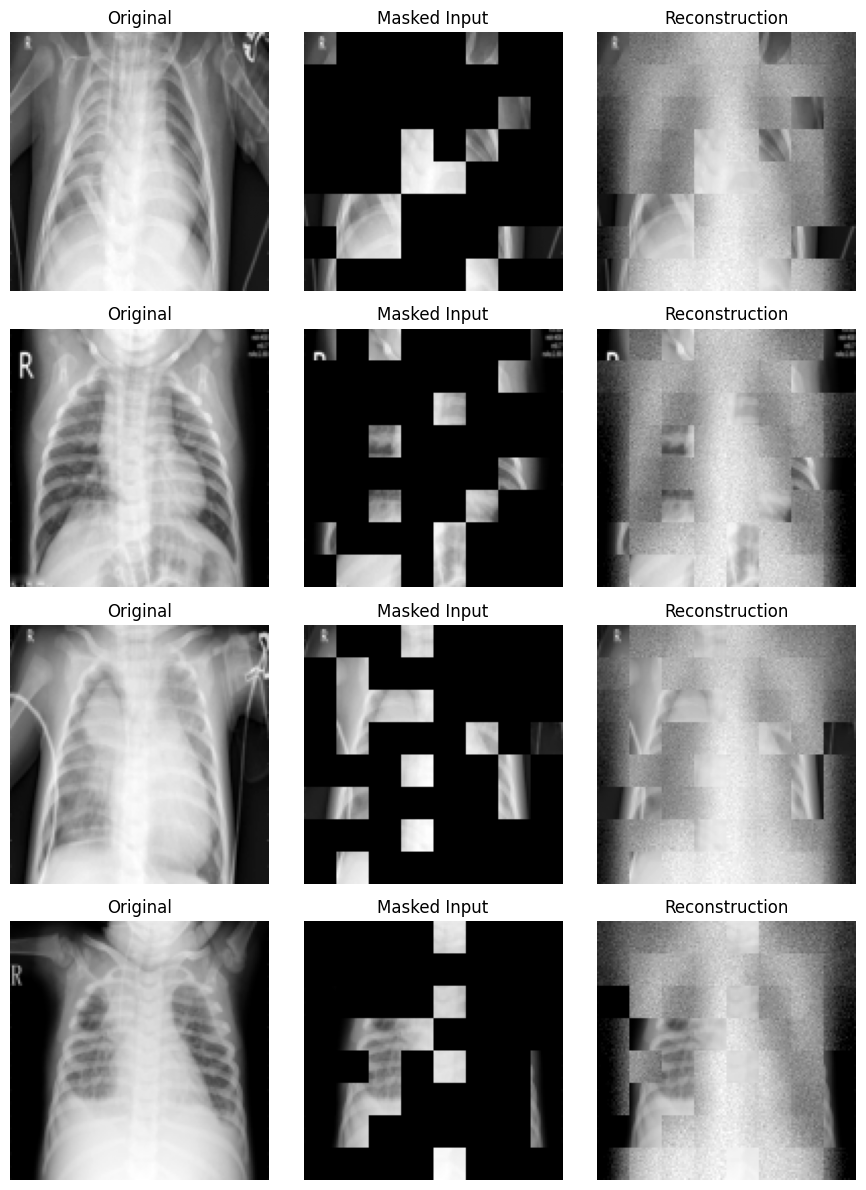

In [ ]:
# 3) VISUALIZE A FEW RECONSTRUCTIONS
import torch
import matplotlib.pyplot as plt
import numpy as np

def show_reconstruction(model, loader, device, num_examples=4):
    model.eval()
    images, _ = next(iter(loader))   # grab first batch
    images = images.to(device)
    with torch.no_grad():
        recon_patches, mask_idx, _ = model(images)  # recon_patches: [B, num_patches, patch_size*patch_size]

    B = images.shape[0]
    fig, axes = plt.subplots(num_examples, 3, figsize=(9, 3 * num_examples))
    patch_size = model.patch_size
    grid_size = model.patch_embed.grid_size
    num_patches = model.num_patches

    for i in range(num_examples):
        # 1) Original image as a 2D array
        orig = images[i].cpu().squeeze(0).numpy()  # shape [128, 128]

        # 2) Build a “masked” version by zeroing out each masked patch
        masked_img = orig.copy()
        idxs = mask_idx[i].cpu().numpy()      # indices of masked patches (e.g. length 32 or 48)

        for idx in idxs:
            row = idx // grid_size
            col = idx % grid_size
            r0, c0 = row * patch_size, col * patch_size
            masked_img[r0:r0 + patch_size, c0:c0 + patch_size] = 0.0  # black out masked patch

        #Build the “reconstructed” image:
        reconstructed = np.zeros_like(orig)  # [128, 128]
        for p in range(num_patches):  # model.num_patches = 64
            row = p // grid_size
            col = p % grid_size
            r0, c0 = row * patch_size, col * patch_size

            if p not in idxs:
                reconstructed[r0:r0 + patch_size, c0:c0 + patch_size] = \
                    orig[r0:r0 + patch_size, c0:c0 + patch_size]
            else:
                pred_vec = recon_patches[i, p].cpu().numpy()
                pred_patch = pred_vec.reshape(patch_size, patch_size)
                pred_patch = np.clip(pred_patch, 0.0, 1.0)
                reconstructed[r0:r0 + patch_size, c0:c0 + patch_size] = pred_patch

        # 4) Plot images
        axes[i, 0].imshow(orig, cmap='gray')
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(masked_img, cmap='gray')
        axes[i, 1].set_title("Masked Input")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(reconstructed, cmap='gray')
        axes[i, 2].set_title("Reconstruction")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Example call on the validation set:
show_reconstruction(model, val_loader, device, num_examples=4)